# **Stadium Pulse**
### *Building sports data visualizations on deadline*

In [36]:
import pandas as pd
from herhoopstats.api import HerHoopStats

import seaborn as sns
import matplotlib.pyplot as plt

## HerHoopStats

In [29]:
api = HerHoopStats(email="nrdevlin@gmail.com", password="Nicar2026")
teams = api.get_teams(min_season=2026, max_season=2026)

In [31]:
big_ten = [
    'UCLA', 'Michigan', 'Michigan St.', 'Ohio St.', 'Maryland',
    'Nebraska', 'Iowa', 'Illinois', 'Minnesota', 'Penn St.',
    'Indiana', 'Purdue', 'Wisconsin', 'Northwestern', 'Rutgers',
    'Oregon', 'Washington', 'Southern California'
]

In [32]:
big_ten_teams = [x for x in teams if x.team in big_ten]
big_ten_teams

[Team(season='2025-26', team='UCLA', games_played=31, wins=30, losses=1, win_pct=96.8, ppg=84.8, opp_ppg=57.4, net_ppg=27.4, pts_per_100_pos=121.2, opp_pts_per_100_pos=82.7, net_pts_per_100_pos=38.5, pace=69.6, link='/stats/ncaa/team/2026/natl/ucla-bruins-womens-basketball-stats-11e8e149-cbe3-4154-af82-12df17ae4e1e/'),
 Team(season='2025-26', team='Ohio St.', games_played=33, wins=26, losses=7, win_pct=78.8, ppg=81.7, opp_ppg=66.2, net_ppg=15.5, pts_per_100_pos=106.6, opp_pts_per_100_pos=86.3, net_pts_per_100_pos=20.4, pace=76.4, link='/stats/ncaa/team/2026/natl/ohio-st-buckeyes-womens-basketball-stats-11e8e149-ca1c-c6ec-af82-12df17ae4e1e/'),
 Team(season='2025-26', team='Iowa', games_played=30, wins=25, losses=5, win_pct=83.3, ppg=78.5, opp_ppg=65.0, net_ppg=13.5, pts_per_100_pos=108.0, opp_pts_per_100_pos=88.9, net_pts_per_100_pos=19.1, pace=72.6, link='/stats/ncaa/team/2026/natl/iowa-hawkeyes-womens-basketball-stats-11e8e149-c886-db4c-af82-12df17ae4e1e/'),
 Team(season='2025-26', te

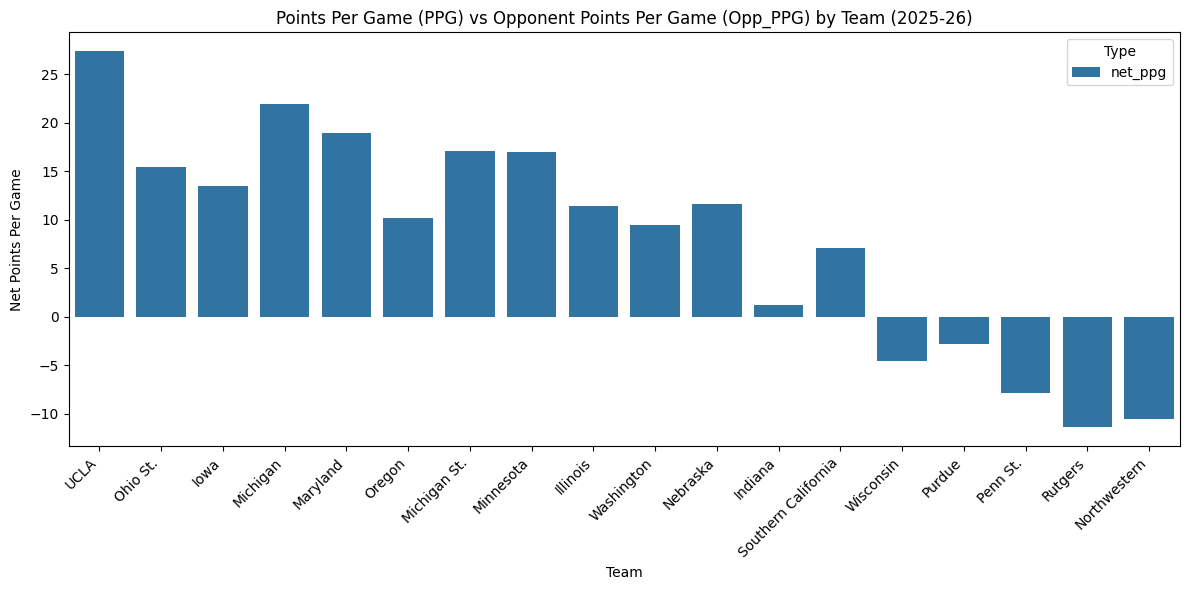

In [ ]:
data = {
    "Team": [team.team for team in big_ten_teams],
    "PPG": [team.ppg for team in big_ten_teams],
    "Opp_PPG": [team.opp_ppg for team in big_ten_teams],
    "net_ppg": [team.net_ppg for team in big_ten_teams],
}

df = pd.DataFrame(data)

plt.figure(figsize=(12, 6))
# df_melt = df.melt(id_vars="Team", value_vars=["PPG", "Opp_PPG"], var_name="Type", value_name="Points Per Game")
df_melt = df.melt(id_vars="Team", value_vars=["net_ppg"], var_name="Type", value_name="Net Points Per Game")
sns.barplot(data=df_melt, x="Team", y="Net Points Per Game", hue="Type")
plt.title("Net Points Per Game (PPG) by Big Ten Team (2025-26)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [44]:
df_melt.drop(columns=['Type'], inplace=True)
df_melt.to_csv('output.csv', index=False)